### 11. Implementing Convolution
- Objective to implement convolution and associated operations from scratch

In [1]:
import numpy as np

rndGen = np.random.default_rng()

X = rndGen.uniform(low=0.0, high=255.0, size=(128, 128)) #Image size of 128,128

In [2]:
def heInitialization(kernel):
    fanIn = kernel.shape[0] * kernel.shape[1]
    std = np.sqrt(2 / fanIn)
    return np.random.normal(0, std, kernel.shape)

In [3]:
def batchNorm(inputImage, gamma=1.0, beta=0.0, epsilon=1e-5):

    #X_cap = x - mean / root( stdDev**2 + e ) ---> Standardization
    #Out = gamma * X_cap + beta -----------------> Affine
    
    mean = np.mean(inputImage)
    variance = np.var(inputImage)

    normalizedImage = (inputImage - mean) / np.sqrt(variance + epsilon) #standardization

    outputImage = gamma * normalizedImage + beta

    return outputImage

In [4]:
def ReLU(inputImage):
    return np.maximum(0, inputImage)

In [5]:
def convolutionForward(inputImage, kernel, stride): # Same padding, O = Floor((N+2P-K)/S) + 1

    inputHeight, inputWidth = inputImage.shape
    kernelHeight, kernelWidth = kernel.shape

    outputHeight = ((inputHeight - kernelHeight) // stride) + 1 #No padding
    outputWidth = ((inputWidth - kernelWidth) // stride) + 1

    outputImage = np.zeros((outputHeight, outputWidth))

    for row in range(outputHeight): #np.dot(currentRegion.ravel(), kernel.ravel()) => Flattened vector, dot prod
        #Here its element wise multiplication and sum
        for col in range(outputWidth):

            startRow = row * stride
            startCol = col * stride

            currentRegion = inputImage[startRow:startRow + kernelHeight, startCol:startCol + kernelWidth]

            outputImage[row, col] = np.sum(currentRegion * kernel)

    return outputImage

In [6]:
k = np.zeros((3,3)) #3*3 Kernel
s = 2 #Stride 2

In [7]:
# Convolution
k = heInitialization(k) #In real life, He is initializing just by using the dimensions, we dont have to initialize zeros and pass k 

z = convolutionForward(X,k,s)

y = ReLU(z)

yOut = batchNorm(y)

In [8]:
print(y)

[[  0.           4.24210523  94.16528429 ...   0.           0.
    0.        ]
 [  0.           0.         116.7932405  ...  75.26448902  63.57210262
   29.29997027]
 [  0.           0.           0.         ...   0.           0.
   38.69420601]
 ...
 [  0.           0.          40.92952233 ...  90.74698942  81.10831216
   51.09945521]
 [ 15.61570193   0.           0.         ...  52.22837536   0.
    0.        ]
 [125.5790447    0.           0.         ...  61.53293132   0.
  125.29983946]]


In [9]:
X.shape

(128, 128)

In [10]:
yOut.shape

(63, 63)

Just for fun, visualizing the input and output

In [11]:
import matplotlib.pyplot as plt

def displayImage(image, title):
    plt.figure(figsize=(3, 3))
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

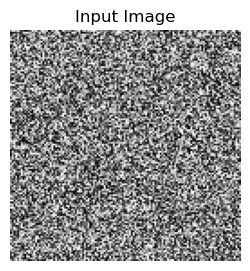

In [12]:
displayImage(X, "Input Image")

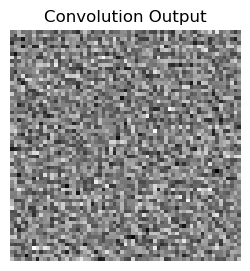

In [13]:
displayImage(z, "Convolution Output")

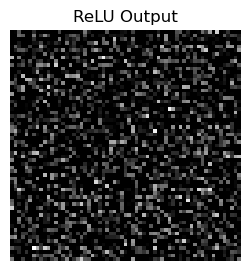

In [14]:
displayImage(y, "ReLU Output")

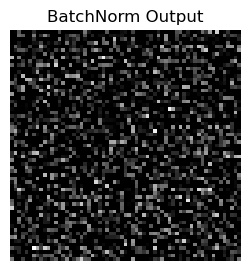

In [15]:
displayImage(yOut, "BatchNorm Output")

### MNIST - Number Detection using CNNs
#### 1. Module : Prepare Dataset

In [16]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

#### 1. Define the Transform

In [17]:
transform = transforms.ToTensor()

#### 2. Download the Dataset

In [18]:
trainDataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testDataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



#### 3. Create the DataLoaders

In [19]:
trainLoader = DataLoader(
    trainDataset,
    batch_size=64,
    shuffle=True
)

testLoader = DataLoader(
    testDataset,
    batch_size=64,
    shuffle=False
)

In [20]:
print(f"Training Samples : {len(trainDataset)}")
print(f"Testing Samples  : {len(testDataset)}")

Training Samples : 60000
Testing Samples  : 10000


#### 2. Module : MNIST Inspection

In [21]:
image, label = trainDataset[0]

print(f"Image Shape : {image.shape}")
print(f"Label       : {label}")

Image Shape : torch.Size([1, 28, 28])
Label       : 5


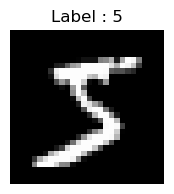

In [23]:
plt.figure(figsize=(2, 2))

plt.imshow(image.squeeze(), cmap="gray")

plt.title(f"Label : {label}")
plt.axis("off")

plt.show()

In [24]:
'''Squeeze dimensions'''
image.squeeze()

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

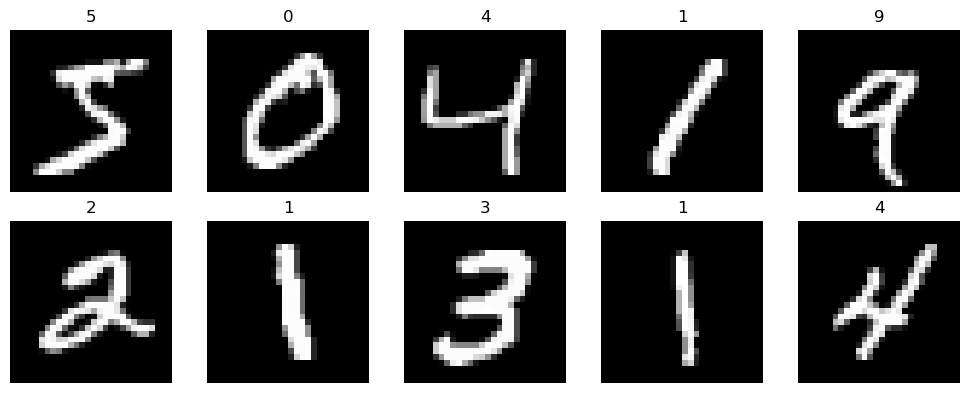

In [29]:
plt.figure(figsize=(10, 4))

for index in range(10):

    image, label = trainDataset[index]

    plt.subplot(2, 5, index + 1)

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(label)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
images, labels = next(iter(trainLoader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


#### 3. Module : CNN Defition

In [35]:
class DigitClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=0
        )

        self.relu = nn.ReLU()

        self.batchNorm = nn.BatchNorm2d(
            num_features=8
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Linear(
            in_features=8 * 26 * 26,
            out_features=10
        )

    def forward(self, x):

        x = self.conv(x)
        x = self.relu(x)
        x = self.batchNorm(x)
        x = self.flatten(x)
        x = self.fc(x)

        return x

#### 4. Module : Forward pass

In [39]:
model = DigitClassifier()

In [37]:
images, labels = next(iter(trainLoader))

In [38]:
x = images

print(f"Input      : {x.shape}")

x = model.conv(x)
print(f"Conv       : {x.shape}")

x = model.relu(x)
print(f"ReLU       : {x.shape}")

x = model.batchNorm(x)
print(f"BatchNorm  : {x.shape}")

x = model.flatten(x)
print(f"Flatten    : {x.shape}")

x = model.fc(x)
print(f"Linear     : {x.shape}")

Input      : torch.Size([64, 1, 28, 28])
Conv       : torch.Size([64, 8, 26, 26])
ReLU       : torch.Size([64, 8, 26, 26])
BatchNorm  : torch.Size([64, 8, 26, 26])
Flatten    : torch.Size([64, 5408])
Linear     : torch.Size([64, 10])


#### 5. Module : Training

In [42]:
model = DigitClassifier()

In [43]:
criterion = nn.CrossEntropyLoss()

In [44]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [45]:
epochs = 5

In [46]:
for epoch in range(epochs):

    for images, labels in trainLoader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step() #Update weights

    print(f"Epoch {epoch + 1}: Loss = {loss.item():.4f}")

Epoch 1: Loss = 0.0347
Epoch 2: Loss = 0.0158
Epoch 3: Loss = 0.0113
Epoch 4: Loss = 0.0125
Epoch 5: Loss = 0.0124


#### 6. Module : Evaluation

In [49]:
model.eval()

correctPredictions = 0
totalPredictions = 0

with torch.no_grad():

    for images, labels in testLoader:

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        correctPredictions += (
            predictions == labels
        ).sum().item()

        totalPredictions += labels.size(0)

accuracy = (
    correctPredictions / totalPredictions
) * 100

print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 97.16%


#### 7. Module : Visualize Predictions

In [50]:
images, labels = next(iter(testLoader))

In [51]:
with torch.no_grad():

    outputs = model(images)

    predictions = torch.argmax(outputs, dim=1)

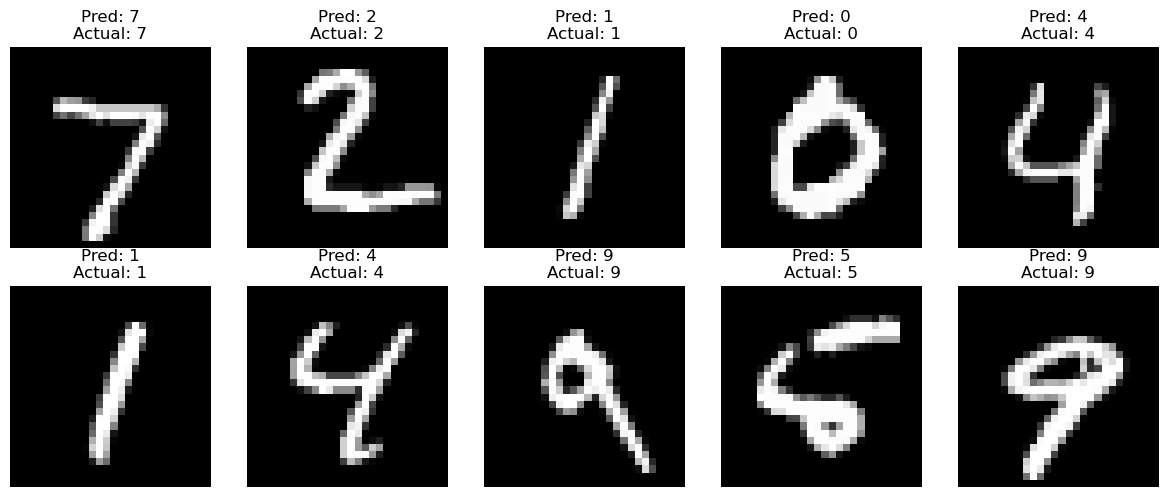

In [52]:
plt.figure(figsize=(12, 5))

for index in range(10):

    plt.subplot(2, 5, index + 1)

    plt.imshow(images[index].squeeze(), cmap="gray")

    predictedLabel = predictions[index].item()
    actualLabel = labels[index].item()

    plt.title(
        f"Pred: {predictedLabel}\nActual: {actualLabel}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

#### 8. Module : Visualize Feature Maps

In [53]:
image, label = testDataset[0]

In [54]:
image = image.unsqueeze(0)

In [55]:
print(image.shape)

torch.Size([1, 1, 28, 28])


In [56]:
model.eval()

with torch.no_grad():

    featureMaps = model.conv(image)

In [57]:
print(featureMaps.shape)

torch.Size([1, 8, 26, 26])


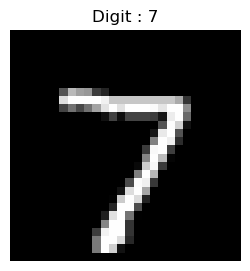

In [58]:
plt.figure(figsize=(3,3))

plt.imshow(image.squeeze(), cmap="gray")

plt.title(f"Digit : {label}")

plt.axis("off")

plt.show()

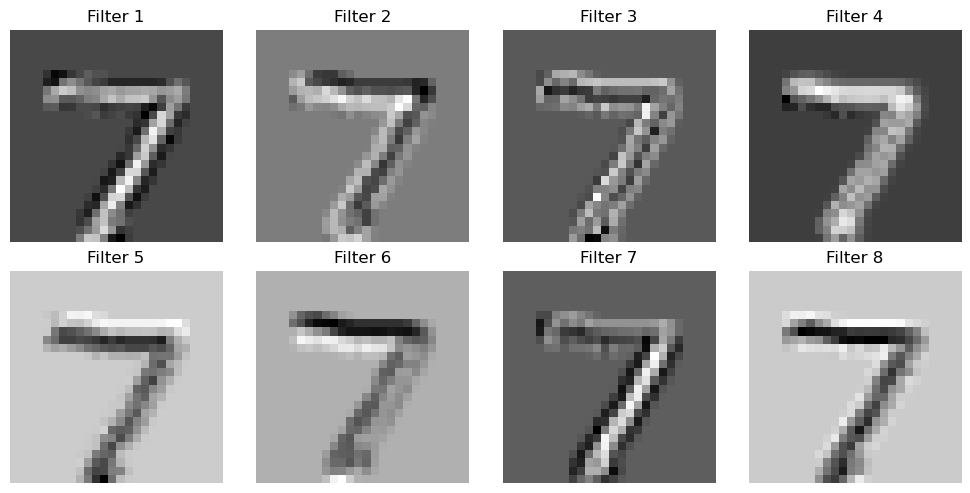

In [59]:
plt.figure(figsize=(10, 5))

for index in range(8):

    plt.subplot(2, 4, index + 1)

    plt.imshow(
        featureMaps[0, index].cpu(),
        cmap="gray"
    )

    plt.title(f"Filter {index + 1}")

    plt.axis("off")

plt.tight_layout()
plt.show()